<a href="https://colab.research.google.com/github/dthompson2003/Digital-Imaging-Final/blob/main/Data/data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("tpapp157/earth-terrain-height-and-segmentation-map-images")


Using Colab cache for faster access to the 'earth-terrain-height-and-segmentation-map-images' dataset.


In [ ]:
print("Path to dataset files:", path)

heightMapData = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith("h.png"):
            full_path = os.path.join(root, file)
            heightMapData.append(full_path)

# Sort heightMapData based on the numerical part of the filename
heightMapData.sort(key=lambda x: int(os.path.basename(x).split('_')[0]))

print("Number of height map files:", len(heightMapData))


for file in heightMapData[:10]:   # show first 10
    print(file)

Path to dataset files: /kaggle/input/earth-terrain-height-and-segmentation-map-images
Number of height map files: 5000
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0001_h.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0002_h.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0003_h.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0004_h.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0005_h.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0006_h.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0007_h.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0008_h.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0009_h.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0010_h.png


In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

processed_height_maps = []

for i, file_path in enumerate(heightMapData):
    # Open the image
    img = Image.open(file_path)

    # Convert image to a NumPy array (float type for division)
    img_array = np.array(img, dtype=np.float32)

    # Find the maximum pixel value in the current image
    max_val = np.max(img_array)

    # Normalize the image array if max_val is not zero
    if max_val > 0:
        normalized_img_array = img_array / max_val
    else:
        normalized_img_array = img_array # Image is all black, no normalization needed

    processed_height_maps.append(normalized_img_array)

print(f"Processed {len(processed_height_maps)} height map images.")
print(f"Example: The maximum pixel value in the first processed image is: {np.max(processed_height_maps[0])}")

Processed 5000 height map images.
Example: The maximum pixel value in the first processed image is: 1.0


Let's visualize the first original and processed height map to see the effect of normalization.

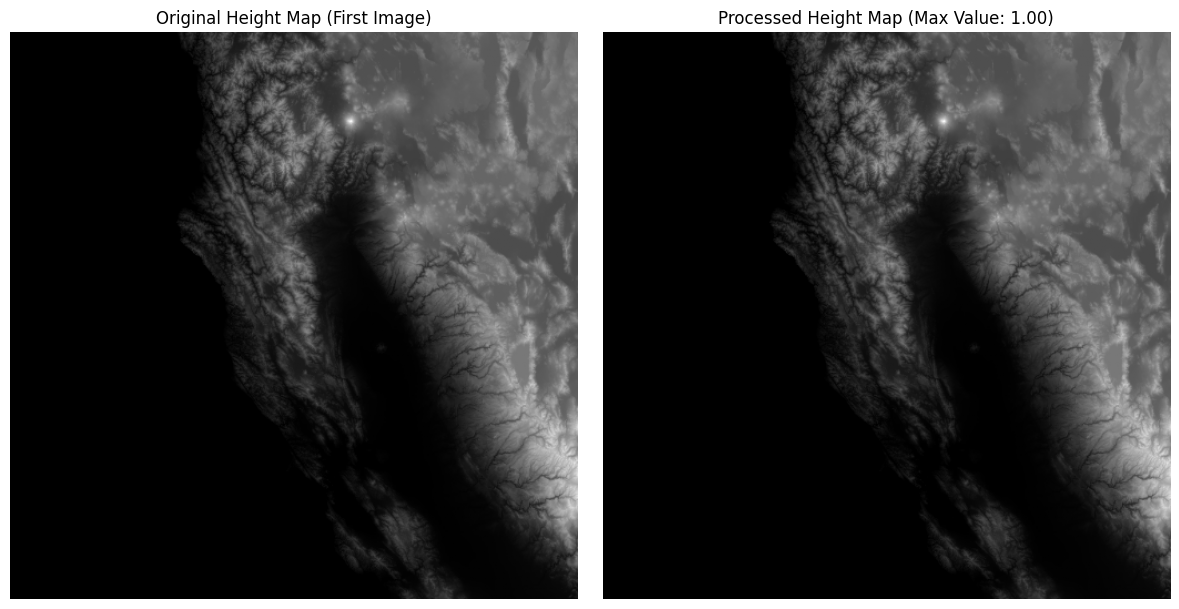

In [ ]:
# Load the first original image for comparison
original_img_path = heightMapData[0]
original_img = Image.open(original_img_path)

# Get the first processed image array
first_processed_img_array = processed_height_maps[0]

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(original_img, cmap='gray')
plt.title('Original Height Map (First Image)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(first_processed_img_array, cmap='gray')
plt.title(f'Processed Height Map (Max Value: {np.max(first_processed_img_array):.2f})')
plt.axis('off')

plt.tight_layout()
plt.show()

Let's visualize the first 5 original and processed height maps.

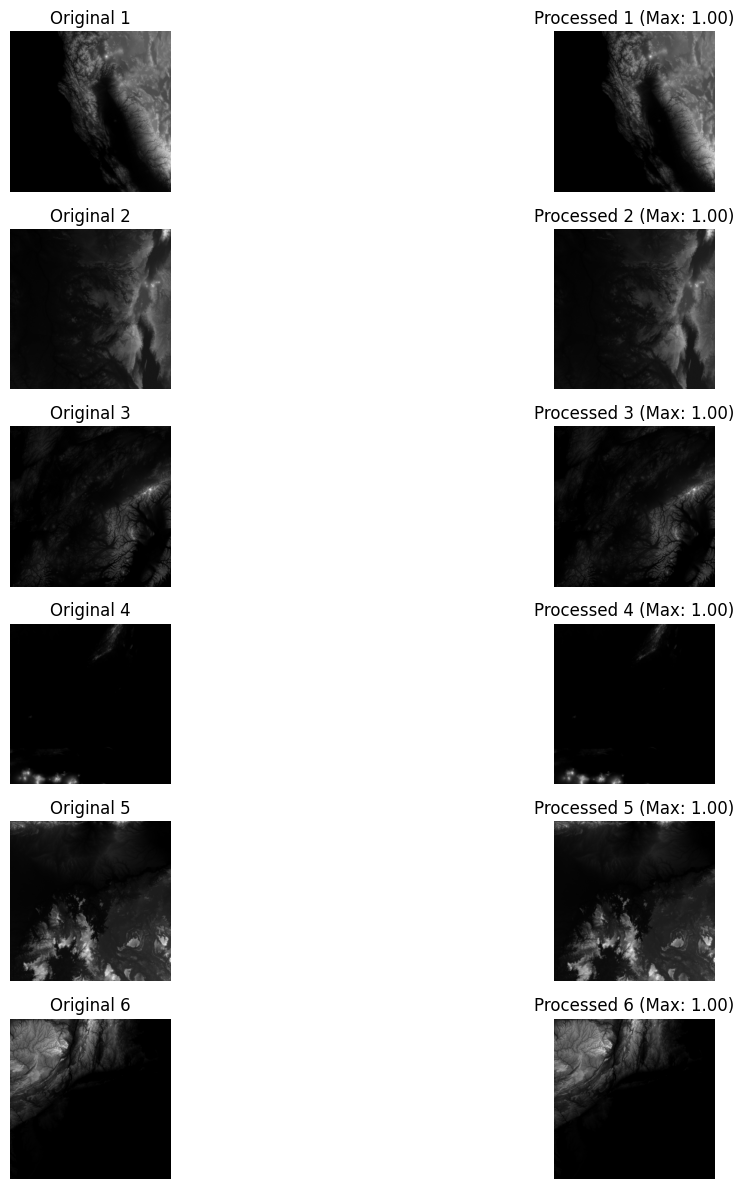

In [ ]:
num_images_to_display = 6

plt.figure(figsize=(15, 2 * num_images_to_display))

for i in range(num_images_to_display):
    # Load the original image
    original_img_path = heightMapData[i]
    original_img = Image.open(original_img_path)

    # Get the processed image array
    processed_img_array = processed_height_maps[i]

    # Plot original image
    plt.subplot(num_images_to_display, 2, 2 * i + 1)
    plt.imshow(original_img, cmap='gray')
    plt.title(f'Original {i+1}')
    plt.axis('off')

    # Plot processed image
    plt.subplot(num_images_to_display, 2, 2 * i + 2)
    plt.imshow(processed_img_array, cmap='gray')
    plt.title(f'Processed {i+1} (Max: {np.max(processed_img_array):.2f})')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:

print("Path to dataset files:", path)
edgeMapData = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith("i2.png"):
            full_path = os.path.join(root, file)
            edgeMapData.append(full_path)

edgeMapData.sort(key=lambda x: int(os.path.basename(x).split('_')[0]))
print("Number of i2 map files:", len(edgeMapData))

for file in edgeMapData[:10]:   # show first 10
    print(file)

Path to dataset files: /kaggle/input/earth-terrain-height-and-segmentation-map-images
Number of i2 map files: 5000
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0001_i2.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0002_i2.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0003_i2.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0004_i2.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0005_i2.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0006_i2.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0007_i2.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0008_i2.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0009_i2.png
/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0010_i2.png


/kaggle/input/earth-terrain-height-and-segmentation-map-images/_dataset/0001_i2.png


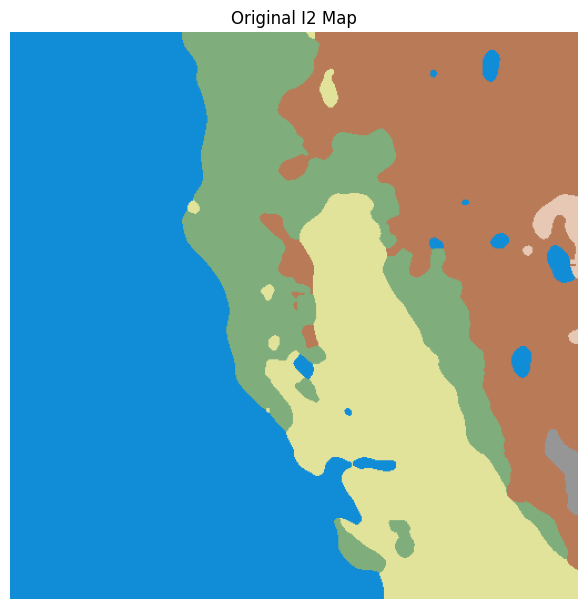

In [ ]:
# Load the first original image for comparison
original_i2_path = edgeMapData[0]
original_i2 = Image.open(original_i2_path)


plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(original_i2)
plt.title('Original I2 Map', print(edgeMapData[0]))
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from skimage import feature

processed_edge_maps = []

for i, file_path in enumerate(edgeMapData):
    # Open the image in grayscale
    img = Image.open(file_path).convert('L')

    # Convert image to a NumPy array
    img_array = np.array(img)

    # Apply Canny edge detection
    # sigma is the standard deviation of the Gaussian filter
    # You might need to adjust sigma and other parameters for optimal results
    edges = feature.canny(img_array, sigma=1)

    processed_edge_maps.append(edges)

print(f"Processed {len(processed_edge_maps)} edge map images.")
print(f"Example: The shape of the first processed edge map is: {processed_edge_maps[0].shape}")

Processed 5000 edge map images.
Example: The shape of the first processed edge map is: (512, 512)


Let's visualize the first original and processed edge map to see the effect of Canny edge detection.

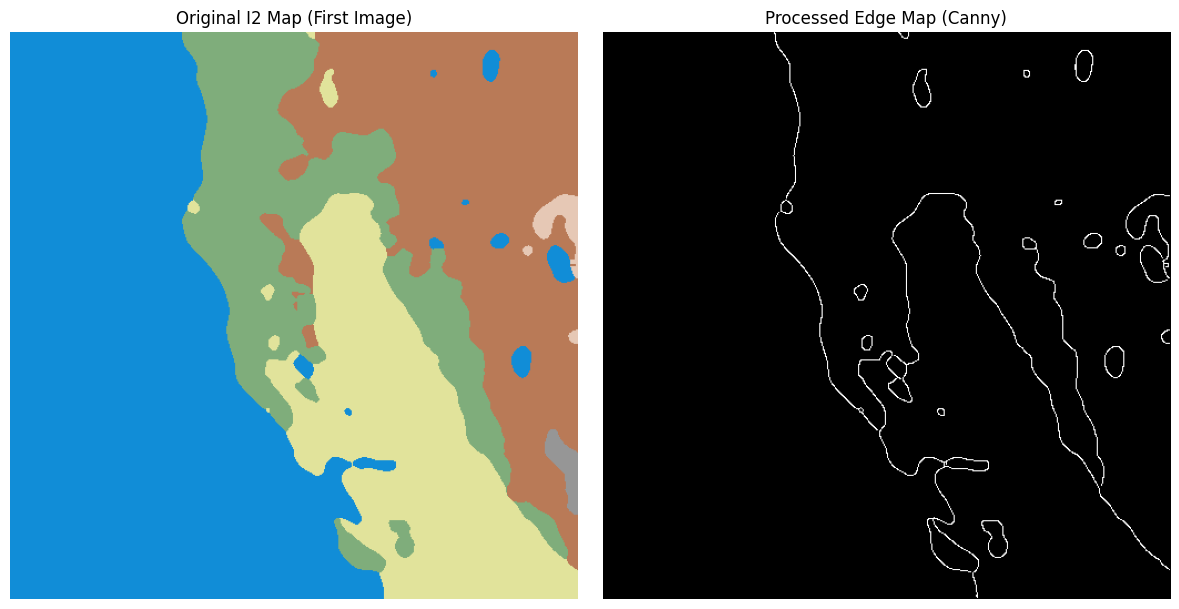

In [ ]:
# Load the first original image for comparison
original_i2_path = edgeMapData[0]
original_i2_img = Image.open(original_i2_path)

# Get the first processed edge map array
first_processed_edge_map = processed_edge_maps[0]

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(original_i2_img, cmap='gray')
plt.title('Original I2 Map (First Image)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(first_processed_edge_map, cmap='gray')
plt.title('Processed Edge Map (Canny)')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os

# Clone the pix2pixHD repository if it doesn't already exist
repo_path = 'pix2pixHD'
if not os.path.exists(repo_path):
    !git clone https://github.com/NVIDIA/pix2pixHD.git
    print(f"Repository '{repo_path}' cloned successfully.")
else:
    print(f"Repository '{repo_path}' already exists. Skipping clone.")

# Navigate into the cloned repository directory
os.chdir(repo_path)
print(f"Current working directory changed to: {os.getcwd()}")

Repository 'pix2pixHD' already exists. Skipping clone.
Current working directory changed to: /content/pix2pixHD


In [ ]:
import numpy as np
from PIL import Image
import os

# 1. Setup Directories
dataset_name = 'my_terrain_data_rgb'
base_path = f'/content/pix2pixHD/datasets/{dataset_name}'
os.makedirs(os.path.join(base_path, 'train_A'), exist_ok=True)
os.makedirs(os.path.join(base_path, 'train_B'), exist_ok=True)

print("Processing and resizing images to 512x512 RGB...")

# 2. Process and Save Images as RGB
for i in range(len(heightMapData)):
    # Load and Resize Edge Map (Input A) - Convert to RGB
    edge_img = Image.open(edgeMapData[i]).convert('RGB').resize((512, 512), Image.BICUBIC)

    # Load and Resize Height Map (Target B) - Convert to RGB
    height_img = Image.open(heightMapData[i]).convert('RGB').resize((512, 512), Image.BICUBIC)

    filename = f'img_{i:04d}.png'

    edge_img.save(os.path.join(base_path, 'train_A', filename))
    height_img.save(os.path.join(base_path, 'train_B', filename))

print(f"Successfully saved {len(heightMapData)} RGB image pairs to {base_path}")

Processing and resizing images to 512x512 RGB...
Successfully saved 5000 RGB image pairs to /content/pix2pixHD/datasets/my_terrain_data_rgb


In [ ]:
# 1. Reset all repository files to original state
!git checkout data/aligned_dataset.py data/base_dataset.py models/pix2pixHD_model.py

# 2. Training run using the new RGB dataset
# Note: input_nc and output_nc now use the default 3
train_cmd = (
    "python train.py "
    "--dataroot ./datasets/my_terrain_data_rgb "
    "--name terrain_pix2pixHD_rgb "
    "--label_nc 0 "
    "--no_instance "
    "--resize_or_crop none "
    "--save_epoch_freq 5 "
    "--gpu_ids 0 "
    "--batchSize 1"
)

print(f"Starting training with RGB dataset...\n{train_cmd}")
!{train_cmd}

Updated 3 paths from the index
Starting training with RGB dataset...
python train.py --dataroot ./datasets/my_terrain_data_rgb --name terrain_pix2pixHD_rgb --label_nc 0 --no_instance --resize_or_crop none --save_epoch_freq 5 --gpu_ids 0 --batchSize 1
------------ Options -------------
batchSize: 1
beta1: 0.5
checkpoints_dir: ./checkpoints
continue_train: False
data_type: 32
dataroot: ./datasets/my_terrain_data_rgb
debug: False
display_freq: 100
display_winsize: 512
feat_num: 3
fineSize: 512
fp16: False
gpu_ids: [0]
input_nc: 3
instance_feat: False
isTrain: True
label_feat: False
label_nc: 0
lambda_feat: 10.0
loadSize: 1024
load_features: False
load_pretrain: 
local_rank: 0
lr: 0.0002
max_dataset_size: inf
model: pix2pixHD
nThreads: 2
n_blocks_global: 9
n_blocks_local: 3
n_clusters: 10
n_downsample_E: 4
n_downsample_global: 4
n_layers_D: 3
n_local_enhancers: 1
name: terrain_pix2pixHD_rgb
ndf: 64
nef: 16
netG: global
ngf: 64
niter: 100
niter_decay: 100
niter_fix_global: 0
no_flip: False


In [ ]:
# Testing Run
test_cmd = (
    "python test.py "
    "--dataroot ./datasets/my_terrain_data_rgb "
    "--name terrain_pix2pixHD_rgb "
    "--label_nc 0 "
    "--no_instance "
    "--resize_or_crop none "
    "--gpu_ids 0 "
)

print(f"Running test...\n{test_cmd}")
!{test_cmd}

In [ ]:
import numpy as np
from IPython.display import HTML, display
from google.colab import output
import cv2
import torch
import base64
import matplotlib.pyplot as plt

canvas_html = """
<div style="border: 1px solid #ccc; padding: 20px; width: fit-content; text-align: center; background-color: #f9f9f9; border-radius: 10px;">
    <canvas id="main_canvas" width="512" height="512" style="border:2px solid #000; cursor: crosshair; background-color: black;"></canvas>
    <br><br>
    <button id="clear_btn" style="padding: 10px 20px; cursor: pointer;">Clear</button>
    <button id="finish_btn" style="padding: 10px 20px; cursor: pointer; background-color: #4CAF50; color: white; border: none; border-radius: 5px;">Run Model</button>
</div>

<script>
    var canvas = document.getElementById('main_canvas');
    var ctx = canvas.getContext('2d');
    var finish_btn = document.getElementById('finish_btn');
    var clear_btn = document.getElementById('clear_btn');
    var drawing = false;

    ctx.strokeStyle = "white";
    ctx.lineWidth = 2;
    ctx.lineCap = "round";
    ctx.lineJoin = "round";

    canvas.addEventListener('mousedown', (e) => { drawing = true; ctx.beginPath(); ctx.moveTo(e.offsetX, e.offsetY); });
    canvas.addEventListener('mousemove', (e) => { if(drawing) { ctx.lineTo(e.offsetX, e.offsetY); ctx.stroke(); } });
    canvas.addEventListener('mouseup', () => { drawing = false; });

    clear_btn.onclick = () => { ctx.clearRect(0, 0, canvas.width, canvas.height); };

    // This function returns a promise that Colab's eval_js will wait for
    var getCanvasData = new Promise(resolve => {
        finish_btn.onclick = () => {
            resolve(canvas.toDataURL('image/png'));
        };
    });
</script>
"""

def get_prediction():
    display(HTML(canvas_html))

    data_url = output.eval_js("getCanvasData")

    try:
        header, encoded = data_url.split(",", 1)
        binary = base64.b64decode(encoded)
        nparr = np.frombuffer(binary, np.uint8)

        # One or the other, think they are the same
        img = cv2.imdecode(nparr, cv2.IMREAD_UNCHANGED)
        img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

        # Correct size assurance
        img = cv2.resize(img_gray, (512, 512), interpolation=cv2.INTER_AREA)

        # Just in case, might not need it since it might already be as RGB
        img_color = cv2.cvtColor(img, cv2.COLOR_BGR2RBG)

        # normalization
        img = img_color.astype(np.float32) / 255.0
        img = (img - 0.5) / 0.5

        # Turn into a tensor
        img_tensor = torch.from_numpy(img)
        img_tensor = img_tensor.permute(2, 0, 1)
        img_tensor = img_tensor.unsqueeze(0).to(device)


        # Testing
        model.eval()
        with torch.no_grad():
            fake = model.inference(img_tensor)
            # or: model(data, mode="inference") depending on the repository strucure

        fake = fake.squeeze().cpu().numpy()
        fake = (fake + 1) / 2
        fake = np.transpose(fake, (1, 2, 0))


        # Display result
        plt.figure(figsize=(5, 5))
        plt.imshow(fake)
        plt.title("Generated Heightmap")
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"Error: {e}")

# Run the test
get_prediction()


# 1. Canvas
# 2. Convert to RGB
# 3. Ensure 512×512
# 4. Normalize to [-1,1]
# 5. Convert to Tensors: (1, 3, 512, 512)
# 6. pix2pixHD Generator
# 7. Output (heightmap)
# 8. Convert to displayable image


